# GLOBE V3 — Two-Stage VAE-Gate + Classifier

The dataset is heavily imbalanced — **United States English (USE) is ~55% of all samples**. Instead of training one 17-class classifier that over-predicts USE, this notebook splits the problem:

1. **VAE gate** — a VAE trained *only on USE samples*. At inference, low reconstruction error → "this is USE."
2. **16-class classifier** — trained *only on the non-USE samples*, where class weights are actually meaningful.

**Important architectural choice:** the VAE operates in **Wav2Vec 2.0 embedding space** (768-d), not raw mel spectrograms. Mel spectrograms are dominated by speaker pitch / phonetic content / recording conditions — accent is a tiny perturbation on top, which means a VAE trained on mel-USE reconstructs French-accented English about as well as American English (recon-error distributions overlap, gate fails). Wav2Vec embeddings already strip much of the speaker/content variance, so accent occupies a much larger fraction of the signal — recon error there actually tracks accent.

Inference: extract W2V embedding → `recon_err(emb) < τ` → predict USE; else forward the original sample through a classifier.

We re-train all four downstream architectures (Capsule, EfficientNet-B0, Wav2Vec 2.0, AST) on the non-USE subset for head-to-head comparison against the baseline `GLOBE_V3_Accent_EDA.ipynb`.


In [1]:
%pip uninstall torchcodec -y --break-system-packages
%pip install datasets huggingface_hub librosa soundfile matplotlib seaborn torch torchvision transformers scikit-learn --break-system-packages

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import io
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import torchvision.models as models
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
np.random.seed(42)
torch.manual_seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Device: {device}")


def decode_audio(ds, idx, target_sr=None):
    raw = ds.data.table.column('audio')[idx].as_py()
    y, sr = librosa.load(io.BytesIO(raw['bytes']), sr=target_sr)
    if target_sr:
        sr = target_sr
    return y, sr

print("decode_audio ready.")

Device: mps
decode_audio ready.


## Data loading

In [3]:
from huggingface_hub import hf_hub_download
from datasets import load_dataset, concatenate_datasets

print("Downloading dev + test parquet files (cached after first run)...")
dev_files = [
    hf_hub_download("MushanW/GLOBE_V3", f"data/dev-{i:05d}-of-00003.parquet", repo_type="dataset")
    for i in range(3)
]
test_files = [
    hf_hub_download("MushanW/GLOBE_V3", f"data/test-{i:05d}-of-00003.parquet", repo_type="dataset")
    for i in range(3)
]

ds_dev = load_dataset("parquet", data_files=dev_files, split="train")
ds_test = load_dataset("parquet", data_files=test_files, split="train")
ds_all = concatenate_datasets([ds_dev, ds_test])
split_labels = ["dev"] * len(ds_dev) + ["test"] * len(ds_test)

meta_cols = [c for c in ds_all.column_names if c != "audio"]
df = ds_all.select_columns(meta_cols).to_pandas()
df["ds_index"] = range(len(df))
df["split"] = split_labels
print(f"Combined: {len(ds_all)} samples | Dev: {len(ds_dev)} | Test: {len(ds_test)}")

Combined: 18782 samples | Dev: 9603 | Test: 9179


## Filtering & dominant-class identification

In [4]:
df = df.dropna(subset=['predicted_accent'])
df = df[df['predicted_accent'].str.strip() != ''].copy()

accent_counts = df['predicted_accent'].value_counts()
MIN_SAMPLES = 20
keep_accents = accent_counts[accent_counts >= MIN_SAMPLES].index.tolist()
df_filtered = df[df['predicted_accent'].isin(keep_accents)].copy()

print(f"Classes (>= {MIN_SAMPLES} samples): {len(keep_accents)}")
print(f"Total samples kept: {len(df_filtered)}")
print(df_filtered['predicted_accent'].value_counts().to_string())

DOM_CLASS = df_filtered['predicted_accent'].value_counts().idxmax()
n_dom = (df_filtered['predicted_accent'] == DOM_CLASS).sum()
print(f"\nDominant class: '{DOM_CLASS}' — {n_dom} samples ({n_dom/len(df_filtered)*100:.1f}%)")

Classes (>= 20 samples): 17
Total samples kept: 18580
predicted_accent
United States English                                            10135
India and South Asia (India, Pakistan, Sri Lanka)                 3913
England English                                                   2017
Canadian English                                                   556
Australian English                                                 543
Southern African (South Africa, Zimbabwe, Namibia)                 255
Irish English                                                      205
Scottish English                                                   170
Malaysian English                                                  160
Filipino                                                           150
New Zealand English                                                140
Hong Kong English                                                  132
Singaporean English                                                 92
Welsh 

## EDA — imbalance focus

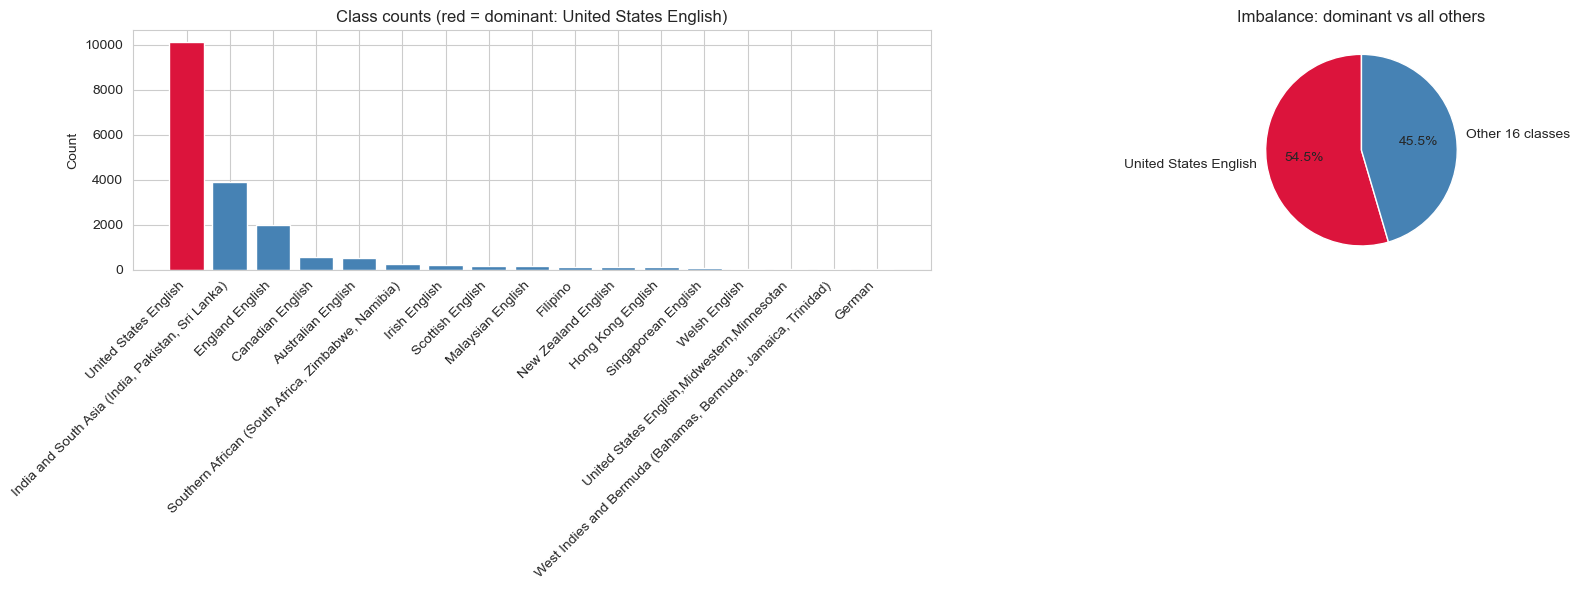

Non-dominant class counts:
predicted_accent
India and South Asia (India, Pakistan, Sri Lanka)                3913
England English                                                  2017
Canadian English                                                  556
Australian English                                                543
Southern African (South Africa, Zimbabwe, Namibia)                255
Irish English                                                     205
Scottish English                                                  170
Malaysian English                                                 160
Filipino                                                          150
New Zealand English                                               140
Hong Kong English                                                 132
Singaporean English                                                92
Welsh English                                                      45
United States English,Midwestern,Minnesotan   

In [5]:
counts = df_filtered['predicted_accent'].value_counts()
colors = ['crimson' if c == DOM_CLASS else 'steelblue' for c in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
axes[0].bar(range(len(counts)), counts.values, color=colors)
axes[0].set_xticks(range(len(counts)))
axes[0].set_xticklabels(counts.index, rotation=45, ha='right')
axes[0].set_title(f'Class counts (red = dominant: {DOM_CLASS})')
axes[0].set_ylabel('Count')

dom = counts.loc[DOM_CLASS]
rest = counts.drop(DOM_CLASS).sum()
axes[1].pie([dom, rest], labels=[DOM_CLASS, f'Other {len(counts)-1} classes'],
            colors=['crimson', 'steelblue'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Imbalance: dominant vs all others')
plt.tight_layout(); plt.show()

print('Non-dominant class counts:')
print(counts.drop(DOM_CLASS).to_string())

## Mel spectrograms (for spectrogram-based classifiers)
The capsule network and EfficientNet need mel spectrograms; the VAE gate and the W2V/AST classifiers don't. Build the spectrograms once here.

In [6]:
SR = 22050
N_MELS = 128
FMAX = 8000
HOP_LENGTH = 512

print("Computing durations...")
durations = []
for i, (_, row) in enumerate(df_filtered.iterrows()):
    y, sr = decode_audio(ds_all, int(row['ds_index']))
    durations.append(len(y) / sr)
    if (i + 1) % 2000 == 0:
        print(f"  {i+1}/{len(df_filtered)}")
df_filtered['duration'] = durations

TARGET_DURATION = float(df_filtered['duration'].median())
TARGET_SAMPLES = int(TARGET_DURATION * SR)
T_DIM = TARGET_SAMPLES // HOP_LENGTH + 1
print(f"\nTarget duration: {TARGET_DURATION:.2f}s ({TARGET_SAMPLES} samples)")
print(f"Mel spec shape: ({N_MELS}, {T_DIM})")

Computing durations...
  2000/18580
  4000/18580
  6000/18580
  8000/18580
  10000/18580
  12000/18580
  14000/18580
  16000/18580
  18000/18580

Target duration: 5.00s (110250 samples)
Mel spec shape: (128, 216)


In [7]:
def audio_to_mel(y, sr, n_mels=N_MELS, fmax=FMAX,
                 target_sr=SR, target_samples=TARGET_SAMPLES, hop_length=HOP_LENGTH):
    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)
    if len(y) < target_samples:
        y = np.pad(y, (0, target_samples - len(y)), mode='constant')
    else:
        y = y[:target_samples]
    mel = librosa.feature.melspectrogram(y=y, sr=target_sr, n_mels=n_mels,
                                         fmax=fmax, hop_length=hop_length)
    return librosa.power_to_db(mel, ref=np.max)


print("Computing mel spectrograms...")
spectrograms, labels_list, ds_indices_list, split_list = [], [], [], []
skipped = 0
for i, (_, row) in enumerate(df_filtered.iterrows()):
    try:
        y, sr = decode_audio(ds_all, int(row['ds_index']))
        spectrograms.append(audio_to_mel(y, sr))
        labels_list.append(row['predicted_accent'])
        ds_indices_list.append(row['ds_index'])
        split_list.append(row['split'])
    except Exception as e:
        skipped += 1
        if skipped <= 3:
            print(f"  Skipped: {e}")
    if (i + 1) % 2000 == 0:
        print(f"  {i+1}/{len(df_filtered)}")

X = np.array(spectrograms)
ds_indices_arr = np.array(ds_indices_list)
splits_arr = np.array(split_list)
labels_arr = np.array(labels_list)
print(f"\nDone. X: {X.shape}, skipped: {skipped}")

Computing mel spectrograms...
  2000/18580
  4000/18580
  6000/18580
  8000/18580
  10000/18580
  12000/18580
  14000/18580
  16000/18580
  18000/18580

Done. X: (18580, 128, 216), skipped: 0


## Splits and label spaces

In [8]:
X_tensor = torch.FloatTensor(X).unsqueeze(1)
print(f"X_tensor: {X_tensor.shape}")

# 17-class for end-to-end eval
le_full = LabelEncoder()
y_full = le_full.fit_transform(labels_arr)
y_full_tensor = torch.LongTensor(y_full)
DOM_IDX_FULL = int(np.where(le_full.classes_ == DOM_CLASS)[0][0])

# 16-class non-USE
nondom_mask = labels_arr != DOM_CLASS
le_other = LabelEncoder()
y_other = le_other.fit_transform(labels_arr[nondom_mask])

dev_indices = np.where(splits_arr == 'dev')[0]
test_indices = np.where(splits_arr == 'test')[0]

train_idx, val_idx = train_test_split(
    dev_indices, test_size=0.15, stratify=y_full[dev_indices], random_state=42)
test_idx = test_indices

is_dom = labels_arr == DOM_CLASS
train_use_idx   = train_idx[is_dom[train_idx]]
val_use_idx     = val_idx[is_dom[val_idx]]
train_other_idx = train_idx[~is_dom[train_idx]]
val_other_idx   = val_idx[~is_dom[val_idx]]
test_other_idx  = test_idx[~is_dom[test_idx]]
test_use_idx    = test_idx[is_dom[test_idx]]

print(f"Train: {len(train_idx)} (USE: {len(train_use_idx)}, non-USE: {len(train_other_idx)})")
print(f"Val:   {len(val_idx)} (USE: {len(val_use_idx)}, non-USE: {len(val_other_idx)})")
print(f"Test:  {len(test_idx)} (USE: {len(test_use_idx)}, non-USE: {len(test_other_idx)})")

# 16-class y aligned to original-row positions
y_other_full = np.full(len(labels_arr), -1, dtype=np.int64)
y_other_full[nondom_mask] = y_other
y_other_tensor = torch.LongTensor(y_other_full.clip(min=0))

y_train_other = y_other_full[train_other_idx]
class_weights = compute_class_weight('balanced',
                                      classes=np.unique(y_train_other),
                                      y=y_train_other)
class_weights = torch.FloatTensor(class_weights)
print(f"16-class weights range: [{class_weights.min():.2f}, {class_weights.max():.2f}]")

X_tensor: torch.Size([18580, 1, 128, 216])
Train: 8074 (USE: 4423, non-USE: 3651)
Val:   1425 (USE: 780, non-USE: 645)
Test:  9081 (USE: 4932, non-USE: 4149)
16-class weights range: [0.14, 22.82]


## Extract Wav2Vec 2.0 features — used by VAE gate AND by Wav2Vec classifier
The VAE will operate on these 768-d embeddings rather than raw mel spectrograms. Wav2Vec strips much of the speaker/content variance, leaving accent as a more salient axis. Extracted once for every sample so we can reuse them downstream.

In [9]:
from transformers import Wav2Vec2FeatureExtractor, Wav2Vec2Model

WAV2VEC_SR = 16000
WAV2VEC_MAX_SEC = 10

print("Loading Wav2Vec 2.0...")
w2v_fe = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base")
w2v_backbone = Wav2Vec2Model.from_pretrained("facebook/wav2vec2-base").to(device)
w2v_backbone.eval()

print(f"Extracting Wav2Vec features for {len(ds_indices_arr)} samples...")
w2v_features = []
for i in range(0, len(ds_indices_arr), 8):
    batch = []
    for idx in ds_indices_arr[i:i+8]:
        y_16k, _ = decode_audio(ds_all, int(idx), target_sr=WAV2VEC_SR)
        y_16k = y_16k[:WAV2VEC_MAX_SEC * WAV2VEC_SR]
        batch.append(y_16k)
    inputs = w2v_fe(batch, sampling_rate=WAV2VEC_SR, return_tensors='pt', padding=True)
    with torch.no_grad():
        out = w2v_backbone(inputs.input_values.to(device))
    w2v_features.append(out.last_hidden_state.mean(dim=1).cpu().numpy())
    if (i + 8) % 800 < 8:
        print(f"  {min(i+8, len(ds_indices_arr))}/{len(ds_indices_arr)}")

w2v_features = np.concatenate(w2v_features)
print(f"Wav2Vec features: {w2v_features.shape}")

del w2v_backbone
if torch.cuda.is_available():
    torch.cuda.empty_cache()

# Standardize features for the VAE — equal weight per dim, comparable MSE
W2V_MEAN = w2v_features[train_use_idx].mean(axis=0)
W2V_STD  = w2v_features[train_use_idx].std(axis=0) + 1e-6
w2v_features_norm = (w2v_features - W2V_MEAN) / W2V_STD
X_w2v = torch.FloatTensor(w2v_features)               # for the W2V downstream classifier
X_w2v_norm = torch.FloatTensor(w2v_features_norm)     # for the VAE
print(f"Standardized using train-USE statistics; shape {X_w2v_norm.shape}")

Loading Wav2Vec 2.0...


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
project_q.bias               | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting Wav2Vec features for 18580 samples...
  800/18580
  1600/18580
  2400/18580
  3200/18580
  4000/18580
  4800/18580
  5600/18580
  6400/18580
  7200/18580
  8000/18580
  8800/18580
  9600/18580
  10400/18580
  11200/18580
  12000/18580
  12800/18580
  13600/18580
  14400/18580
  15200/18580
  16000/18580
  16800/18580
  17600/18580
  18400/18580
Wav2Vec features: (18580, 768)
Standardized using train-USE statistics; shape torch.Size([18580, 768])


## VAE on Wav2Vec embeddings (USE only)
Small MLP VAE — input is a 768-d embedding, not a 2D spectrogram.

In [10]:
LATENT_DIM = 32
BETA = 1e-3


class FeatVAE(nn.Module):
    def __init__(self, in_dim=768, latent_dim=32):
        super().__init__()
        self.enc = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU(),
        )
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        self.dec = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, in_dim),
        )

    def encode(self, x):
        h = self.enc(x)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        std = (0.5 * logvar).exp()
        return mu + std * torch.randn_like(std)

    def decode(self, z):
        return self.dec(z)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        return self.decode(z), mu, logvar


vae = FeatVAE(in_dim=w2v_features.shape[1], latent_dim=LATENT_DIM).to(device)
with torch.no_grad():
    sample = torch.zeros(2, w2v_features.shape[1]).to(device)
    out, mu, lv = vae(sample)
    print(f"VAE shape check: in {sample.shape} -> out {out.shape}, mu {mu.shape}")
    assert out.shape == sample.shape

print(f"VAE params: {sum(p.numel() for p in vae.parameters()):,}")

VAE shape check: in torch.Size([2, 768]) -> out torch.Size([2, 768]), mu torch.Size([2, 32])
VAE params: 472,640


In [11]:
def vae_loss(x, x_hat, mu, logvar, beta=BETA):
    recon = F.mse_loss(x_hat, x, reduction='mean')
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon + beta * kl, recon.item(), kl.item()


X_train_use = X_w2v_norm[train_use_idx]
X_val_use   = X_w2v_norm[val_use_idx]
print(f"VAE train: {len(X_train_use)} | val: {len(X_val_use)}")

train_use_loader = DataLoader(TensorDataset(X_train_use, X_train_use),
                               batch_size=64, shuffle=True)
val_use_loader = DataLoader(TensorDataset(X_val_use, X_val_use), batch_size=64)

VAE_EPOCHS = 80
opt = torch.optim.Adam(vae.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)

vae_train_recon, vae_val_recon, vae_train_kl, vae_val_kl = [], [], [], []
best_val_recon = float('inf')

for epoch in range(VAE_EPOCHS):
    vae.train()
    tr_r, tr_k, tr_n = 0., 0., 0
    for xb, _ in train_use_loader:
        xb = xb.to(device)
        opt.zero_grad()
        x_hat, mu, lv = vae(xb)
        loss, r, k = vae_loss(xb, x_hat, mu, lv)
        loss.backward()
        opt.step()
        tr_r += r * len(xb); tr_k += k * len(xb); tr_n += len(xb)

    vae.eval()
    va_r, va_k, va_n = 0., 0., 0
    with torch.no_grad():
        for xb, _ in val_use_loader:
            xb = xb.to(device)
            x_hat, mu, lv = vae(xb)
            _, r, k = vae_loss(xb, x_hat, mu, lv)
            va_r += r * len(xb); va_k += k * len(xb); va_n += len(xb)

    tr_r, va_r = tr_r / tr_n, va_r / va_n
    tr_k, va_k = tr_k / tr_n, va_k / va_n
    vae_train_recon.append(tr_r); vae_val_recon.append(va_r)
    vae_train_kl.append(tr_k); vae_val_kl.append(va_k)
    sched.step(va_r)

    if va_r < best_val_recon:
        best_val_recon = va_r
        torch.save(vae.state_dict(), 'best_feat_vae_globe.pth')

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d}/{VAE_EPOCHS} | "
              f"Train recon {tr_r:.4f} kl {tr_k:.3f} | Val recon {va_r:.4f} kl {va_k:.3f}")

print(f"\nBest val recon: {best_val_recon:.4f}")

VAE train: 4423 | val: 780
Epoch  10/80 | Train recon 0.2042 kl 4.584 | Val recon 0.2138 kl 4.630
Epoch  20/80 | Train recon 0.1615 kl 4.492 | Val recon 0.1758 kl 4.545
Epoch  30/80 | Train recon 0.1395 kl 4.386 | Val recon 0.1634 kl 4.314
Epoch  40/80 | Train recon 0.1321 kl 4.289 | Val recon 0.1586 kl 4.340
Epoch  50/80 | Train recon 0.1272 kl 4.219 | Val recon 0.1575 kl 4.291
Epoch  60/80 | Train recon 0.1220 kl 4.161 | Val recon 0.1561 kl 4.206
Epoch  70/80 | Train recon 0.1142 kl 4.145 | Val recon 0.1511 kl 4.124
Epoch  80/80 | Train recon 0.1105 kl 4.133 | Val recon 0.1498 kl 4.142

Best val recon: 0.1495


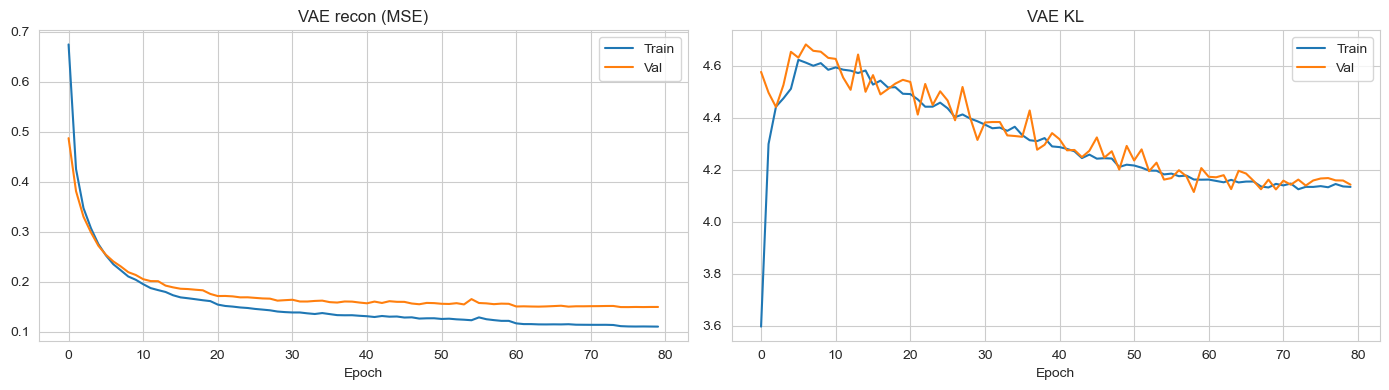

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(vae_train_recon, label='Train')
axes[0].plot(vae_val_recon, label='Val')
axes[0].set_title('VAE recon (MSE)'); axes[0].set_xlabel('Epoch'); axes[0].legend()
axes[1].plot(vae_train_kl, label='Train')
axes[1].plot(vae_val_kl, label='Val')
axes[1].set_title('VAE KL'); axes[1].set_xlabel('Epoch'); axes[1].legend()
plt.tight_layout(); plt.show()

## Gate threshold selection (Wav2Vec recon-error space)

Val USE recon  — mean 0.1495, std 0.0878
Val nUSE recon — mean 0.1775, std 0.1301


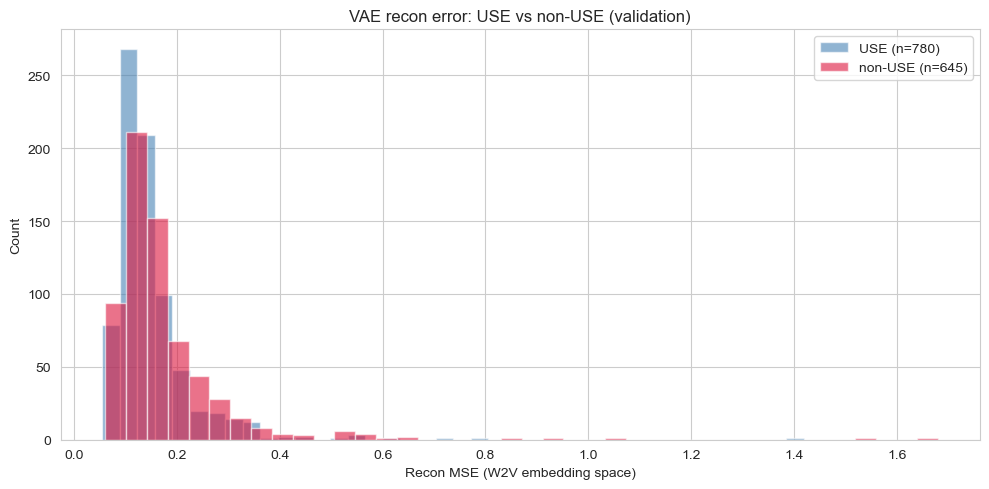

ROC-AUC (recon error as non-USE detector): 0.593


In [13]:
vae.load_state_dict(torch.load('best_feat_vae_globe.pth', weights_only=True))
vae.eval()


def feat_recon_errors(vae, X_subset, batch_size=128):
    errs = []
    loader = DataLoader(TensorDataset(X_subset), batch_size=batch_size)
    with torch.no_grad():
        for (xb,) in loader:
            xb = xb.to(device)
            x_hat, _, _ = vae(xb)
            err = ((x_hat - xb) ** 2).mean(dim=1)
            errs.append(err.cpu().numpy())
    return np.concatenate(errs)


err_val_use = feat_recon_errors(vae, X_w2v_norm[val_use_idx])
err_val_other = feat_recon_errors(vae, X_w2v_norm[val_other_idx])

print(f"Val USE recon  — mean {err_val_use.mean():.4f}, std {err_val_use.std():.4f}")
print(f"Val nUSE recon — mean {err_val_other.mean():.4f}, std {err_val_other.std():.4f}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(err_val_use, bins=40, alpha=0.6, label=f'USE (n={len(err_val_use)})', color='steelblue')
ax.hist(err_val_other, bins=40, alpha=0.6, label=f'non-USE (n={len(err_val_other)})', color='crimson')
ax.set_xlabel('Recon MSE (W2V embedding space)'); ax.set_ylabel('Count')
ax.set_title('VAE recon error: USE vs non-USE (validation)')
ax.legend(); plt.tight_layout(); plt.show()

y_bin = np.concatenate([np.zeros(len(err_val_use)), np.ones(len(err_val_other))])
err_bin = np.concatenate([err_val_use, err_val_other])
auc = roc_auc_score(y_bin, err_bin)
print(f"ROC-AUC (recon error as non-USE detector): {auc:.3f}")
if auc < 0.70:
    print("  WARNING: AUC < 0.70 — the gate is still weak. Consider larger latent_dim or more epochs.")

In [14]:
candidates = np.linspace(err_bin.min(), err_bin.max(), 400)
best_tau, best_bal = None, -1
for tau in candidates:
    use_recall = (err_val_use < tau).mean()
    other_recall = (err_val_other >= tau).mean()
    bal = 0.5 * (use_recall + other_recall)
    if bal > best_bal:
        best_bal, best_tau = bal, tau

tau_p95 = float(np.percentile(err_val_use, 95))
print(f"Balanced-acc-optimal tau: {best_tau:.4f} (balanced acc {best_bal:.3f})")
print(f"  USE-recall:     {(err_val_use < best_tau).mean():.3f}")
print(f"  non-USE-recall: {(err_val_other >= best_tau).mean():.3f}")
print(f"\n95th-pct-of-USE tau: {tau_p95:.4f}")
print(f"  USE-recall:     {(err_val_use < tau_p95).mean():.3f}")
print(f"  non-USE-recall: {(err_val_other >= tau_p95).mean():.3f}")

TAU = best_tau
print(f"\nUsing TAU = {TAU:.4f}")

Balanced-acc-optimal tau: 0.1241 (balanced acc 0.568)
  USE-recall:     0.456
  non-USE-recall: 0.679

95th-pct-of-USE tau: 0.2900
  USE-recall:     0.950
  non-USE-recall: 0.079

Using TAU = 0.1241


## Downstream classifier — shared utilities

In [15]:
num_other = len(le_other.classes_)
print(f"16-class label space: {num_other} classes")

def make_loaders(X_src, idx_train, idx_val, idx_test, batch_size=32, train_shuffle=True):
    return (
        DataLoader(TensorDataset(X_src[idx_train], y_other_tensor[idx_train]),
                    batch_size=batch_size, shuffle=train_shuffle),
        DataLoader(TensorDataset(X_src[idx_val],   y_other_tensor[idx_val]),   batch_size=batch_size),
        DataLoader(TensorDataset(X_src[idx_test],  y_other_tensor[idx_test]),  batch_size=batch_size),
    )


def train_standard(model, train_loader, val_loader, num_epochs, lr, device,
                    class_weights=None, name='model'):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)
    criterion = nn.CrossEntropyLoss(
        weight=class_weights.to(device) if class_weights is not None else None)
    t_losses, v_losses, t_accs, v_accs = [], [], [], []
    best_val_acc = 0
    for epoch in range(num_epochs):
        model.train()
        ls, c, t = 0., 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward(); optimizer.step()
            ls += loss.item() * len(yb); c += (logits.argmax(1) == yb).sum().item(); t += len(yb)
        tl, ta = ls / t, c / t
        model.eval()
        ls, c, t = 0., 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = criterion(logits, yb)
                ls += loss.item() * len(yb); c += (logits.argmax(1) == yb).sum().item(); t += len(yb)
        vl, va = ls / t, c / t
        scheduler.step(vl)
        t_losses.append(tl); v_losses.append(vl); t_accs.append(ta); v_accs.append(va)
        if va > best_val_acc:
            best_val_acc = va
            torch.save(model.state_dict(), f'best_{name}_twostage.pth')
        if (epoch + 1) % 5 == 0:
            print(f"  Epoch {epoch+1:3d}/{num_epochs} | Train {tl:.4f}/{ta:.3f} | Val {vl:.4f}/{va:.3f}")
    print(f"  Best val acc: {best_val_acc:.3f}")
    return t_losses, v_losses, t_accs, v_accs


def eval_classifier(model, loader, device, name='Model'):
    model.eval()
    p, l = [], []
    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb.to(device))
            p.extend(logits.argmax(1).cpu().numpy())
            l.extend(yb.numpy())
    p, l = np.array(p), np.array(l)
    acc = (p == l).mean()
    print(f"{name} non-USE test acc: {acc:.3f}")
    return acc, p, l


class FeatureClassifier(nn.Module):
    def __init__(self, in_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes))
    def forward(self, x):
        return self.net(x)

clf_results = {}

16-class label space: 16 classes


### Model 1: Capsule Network (weighted margin loss, non-USE only)

In [16]:
def squash(x, dim=-1):
    sq = (x ** 2).sum(dim=dim, keepdim=True)
    return (sq / (1 + sq)) * x / (sq.sqrt() + 1e-8)


class MPSAdaptiveAvgPool2d(nn.Module):
    def __init__(self, output_size):
        super().__init__()
        self.output_size = output_size
    def forward(self, x):
        if x.device.type == 'mps':
            return F.adaptive_avg_pool2d(x.cpu(), self.output_size).to(x.device)
        return F.adaptive_avg_pool2d(x, self.output_size)


class PrimaryCapsules(nn.Module):
    def __init__(self, in_channels, num_capsules, capsule_dim, kernel_size, stride):
        super().__init__()
        self.capsule_dim = capsule_dim
        self.conv = nn.Conv2d(in_channels, num_capsules * capsule_dim,
                              kernel_size=kernel_size, stride=stride, padding=1)
    def forward(self, x):
        out = self.conv(x); b, _, h, w = out.shape
        out = out.view(b, -1, self.capsule_dim, h, w).permute(0,1,3,4,2).contiguous()
        return squash(out.view(b, -1, self.capsule_dim))


class ClassCapsules(nn.Module):
    def __init__(self, num_in, dim_in, num_classes, dim_out, num_routing=3):
        super().__init__()
        self.num_classes = num_classes; self.num_routing = num_routing
        self.W = nn.Parameter(torch.randn(1, num_in, num_classes, dim_out, dim_in) * 0.01)
    def forward(self, x):
        bs = x.size(0)
        x = x[:, :, None, :, None]
        u_hat = (self.W @ x).squeeze(-1)
        b = torch.zeros(bs, u_hat.size(1), self.num_classes, device=u_hat.device)
        for i in range(self.num_routing):
            c = F.softmax(b, dim=2)
            v = squash((c.unsqueeze(-1) * u_hat).sum(dim=1))
            if i < self.num_routing - 1:
                b = b + (u_hat * v.unsqueeze(1)).sum(dim=-1)
        return v


class CapsuleNetwork(nn.Module):
    def __init__(self, num_classes, primary_caps=8, primary_dim=8, class_dim=16):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 64, 5, stride=2, padding=2), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, stride=2, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 256, 3, stride=2, padding=1), nn.BatchNorm2d(256), nn.ReLU(),
            MPSAdaptiveAvgPool2d((4, 8)),
        )
        self.primary_caps = PrimaryCapsules(256, primary_caps, primary_dim, 3, 1)
        self.class_caps = ClassCapsules(primary_caps * 4 * 8, primary_dim, num_classes, class_dim, 3)
    def forward(self, x):
        x = self.features(x); x = self.primary_caps(x)
        return self.class_caps(x).norm(dim=-1)


def margin_loss_weighted(probs, targets, num_classes, weights=None,
                          m_plus=0.9, m_minus=0.1, lam=0.5):
    one_hot = F.one_hot(targets, num_classes).float()
    pos = one_hot * F.relu(m_plus - probs) ** 2
    neg = lam * (1 - one_hot) * F.relu(probs - m_minus) ** 2
    per = (pos + neg).sum(dim=-1)
    if weights is not None:
        per = per * weights[targets]
    return per.mean()


caps_train, caps_val, caps_test = make_loaders(
    X_tensor, train_other_idx, val_other_idx, test_other_idx, batch_size=32)
caps_model = CapsuleNetwork(num_classes=num_other).to(device)
cw = class_weights.to(device)
print(f"Capsule params: {sum(p.numel() for p in caps_model.parameters()):,}")

CAPS_EPOCHS = 50
opt = torch.optim.Adam(caps_model.parameters(), lr=1e-3)
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=5, factor=0.5)
caps_tl, caps_vl, caps_ta, caps_va = [], [], [], []
best_va = 0
for epoch in range(CAPS_EPOCHS):
    caps_model.train()
    ls, c, t = 0., 0, 0
    for xb, yb in caps_train:
        xb, yb = xb.to(device), yb.to(device)
        opt.zero_grad()
        probs = caps_model(xb)
        loss = margin_loss_weighted(probs, yb, num_other, weights=cw)
        loss.backward(); opt.step()
        ls += loss.item() * len(yb); c += (probs.argmax(1) == yb).sum().item(); t += len(yb)
    tl, ta = ls / t, c / t
    caps_model.eval()
    ls, c, t = 0., 0, 0
    with torch.no_grad():
        for xb, yb in caps_val:
            xb, yb = xb.to(device), yb.to(device)
            probs = caps_model(xb)
            loss = margin_loss_weighted(probs, yb, num_other, weights=cw)
            ls += loss.item() * len(yb); c += (probs.argmax(1) == yb).sum().item(); t += len(yb)
    vl, va = ls / t, c / t
    sched.step(vl)
    caps_tl.append(tl); caps_vl.append(vl); caps_ta.append(ta); caps_va.append(va)
    if va > best_va:
        best_va = va; torch.save(caps_model.state_dict(), 'best_capsule_twostage.pth')
    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1:3d}/{CAPS_EPOCHS} | Train {tl:.4f}/{ta:.3f} | Val {vl:.4f}/{va:.3f}")

print(f"Best val: {best_va:.3f}")
caps_model.load_state_dict(torch.load('best_capsule_twostage.pth', weights_only=True))
acc, preds, labels = eval_classifier(caps_model, caps_test, device, 'Capsule')
clf_results['Capsule Network'] = {
    'model': caps_model, 'test_acc_other': acc, 'preds_other': preds, 'labels_other': labels,
    'val_accs': caps_va, 'val_losses': caps_vl, 'kind': 'spec'
}

Capsule params: 1,043,392
Epoch   5/50 | Train 0.5441/0.084 | Val 0.5630/0.040
Epoch  10/50 | Train 0.4643/0.118 | Val 0.6160/0.081
Epoch  15/50 | Train 0.3538/0.209 | Val 0.6220/0.096
Epoch  20/50 | Train 0.2940/0.286 | Val 0.6196/0.116
Epoch  25/50 | Train 0.2632/0.343 | Val 0.6179/0.129
Epoch  30/50 | Train 0.2482/0.359 | Val 0.6241/0.144
Epoch  35/50 | Train 0.2437/0.374 | Val 0.6265/0.132
Epoch  40/50 | Train 0.2377/0.382 | Val 0.6268/0.135
Epoch  45/50 | Train 0.2348/0.383 | Val 0.6276/0.132
Epoch  50/50 | Train 0.2330/0.393 | Val 0.6298/0.136
Best val: 0.144
Capsule non-USE test acc: 0.136


### Model 2: EfficientNet-B0

In [17]:
X_eff_norm = (X_tensor - X_tensor.min()) / (X_tensor.max() - X_tensor.min() + 1e-8)
X_eff = F.interpolate(X_eff_norm, size=(224, 224), mode='bilinear', align_corners=False)
X_eff = X_eff.expand(-1, 3, -1, -1).contiguous()
del X_eff_norm

eff_train, eff_val, eff_test = make_loaders(
    X_eff, train_other_idx, val_other_idx, test_other_idx, batch_size=32)

eff_net = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
eff_net.classifier[1] = nn.Linear(eff_net.classifier[1].in_features, num_other)
eff_net = eff_net.to(device)
print(f"EfficientNet-B0 params: {sum(p.numel() for p in eff_net.parameters()):,}")

tl, vl, ta, va = train_standard(eff_net, eff_train, eff_val,
                                 num_epochs=30, lr=1e-4, device=device,
                                 class_weights=class_weights, name='efficientnet')
eff_net.load_state_dict(torch.load('best_efficientnet_twostage.pth', weights_only=True))
acc, preds, labels = eval_classifier(eff_net, eff_test, device, 'EfficientNet-B0')
clf_results['EfficientNet-B0'] = {
    'model': eff_net, 'test_acc_other': acc, 'preds_other': preds, 'labels_other': labels,
    'val_accs': va, 'val_losses': vl, 'kind': 'eff', 'X_eff': X_eff
}

EfficientNet-B0 params: 4,028,044
  Epoch   5/30 | Train 1.4057/0.319 | Val 2.6724/0.205
  Epoch  10/30 | Train 0.5038/0.640 | Val 3.2114/0.338
  Epoch  15/30 | Train 0.3539/0.756 | Val 3.5359/0.381
  Epoch  20/30 | Train 0.2690/0.791 | Val 3.7554/0.428
  Epoch  25/30 | Train 0.2570/0.792 | Val 3.7434/0.445
  Epoch  30/30 | Train 0.2437/0.803 | Val 3.7882/0.420
  Best val acc: 0.445
EfficientNet-B0 non-USE test acc: 0.447


### Model 3: Wav2Vec 2.0 classifier (reusing the features extracted above)

In [18]:
w2v_train, w2v_val, w2v_test = make_loaders(
    X_w2v, train_other_idx, val_other_idx, test_other_idx, batch_size=32)

w2v_clf = FeatureClassifier(X_w2v.shape[1], num_other).to(device)
print(f"Wav2Vec clf params: {sum(p.numel() for p in w2v_clf.parameters()):,}")

tl, vl, ta, va = train_standard(w2v_clf, w2v_train, w2v_val,
                                 num_epochs=50, lr=1e-3, device=device,
                                 class_weights=class_weights, name='wav2vec2')
w2v_clf.load_state_dict(torch.load('best_wav2vec2_twostage.pth', weights_only=True))
acc, preds, labels = eval_classifier(w2v_clf, w2v_test, device, 'Wav2Vec 2.0')
clf_results['Wav2Vec 2.0'] = {
    'model': w2v_clf, 'test_acc_other': acc, 'preds_other': preds, 'labels_other': labels,
    'val_accs': va, 'val_losses': vl, 'kind': 'feat', 'X_feat': X_w2v
}

Wav2Vec clf params: 200,976
  Epoch   5/50 | Train 2.6055/0.167 | Val 2.6493/0.135
  Epoch  10/50 | Train 2.4728/0.146 | Val 2.5822/0.116
  Epoch  15/50 | Train 2.3206/0.158 | Val 2.5368/0.349
  Epoch  20/50 | Train 2.1633/0.172 | Val 2.5181/0.200
  Epoch  25/50 | Train 1.9968/0.211 | Val 2.5546/0.189
  Epoch  30/50 | Train 1.8718/0.228 | Val 2.5177/0.248
  Epoch  35/50 | Train 1.8119/0.270 | Val 2.4935/0.265
  Epoch  40/50 | Train 1.7775/0.263 | Val 2.5015/0.243
  Epoch  45/50 | Train 1.7543/0.259 | Val 2.5014/0.239
  Epoch  50/50 | Train 1.7456/0.258 | Val 2.5025/0.250
  Best val acc: 0.349
Wav2Vec 2.0 non-USE test acc: 0.350


### Model 4: Audio Spectrogram Transformer (frozen)

In [19]:
from transformers import ASTFeatureExtractor, ASTModel

AST_SR = 16000
AST_MAX_SEC = 10

print("Loading AST...")
ast_fe = ASTFeatureExtractor.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593")
ast_backbone = ASTModel.from_pretrained("MIT/ast-finetuned-audioset-10-10-0.4593").to(device)
ast_backbone.eval()

print("Extracting AST features...")
ast_features = []
for i in range(0, len(ds_indices_arr), 8):
    batch = []
    for idx in ds_indices_arr[i:i+8]:
        y_16k, _ = decode_audio(ds_all, int(idx), target_sr=AST_SR)
        y_16k = y_16k[:AST_MAX_SEC * AST_SR]
        batch.append(y_16k)
    inputs = ast_fe(batch, sampling_rate=AST_SR, return_tensors='pt', padding=True)
    with torch.no_grad():
        out = ast_backbone(inputs.input_values.to(device))
    ast_features.append(out.pooler_output.cpu().numpy())
    if (i + 8) % 800 < 8:
        print(f"  {min(i+8, len(ds_indices_arr))}/{len(ds_indices_arr)}")

ast_features = np.concatenate(ast_features)
print(f"AST features: {ast_features.shape}")

del ast_backbone
if torch.cuda.is_available():
    torch.cuda.empty_cache()

X_ast = torch.FloatTensor(ast_features)
ast_train, ast_val, ast_test = make_loaders(
    X_ast, train_other_idx, val_other_idx, test_other_idx, batch_size=32)

ast_clf = FeatureClassifier(ast_features.shape[1], num_other).to(device)
print(f"AST clf params: {sum(p.numel() for p in ast_clf.parameters()):,}")

tl, vl, ta, va = train_standard(ast_clf, ast_train, ast_val,
                                 num_epochs=50, lr=1e-3, device=device,
                                 class_weights=class_weights, name='ast')
ast_clf.load_state_dict(torch.load('best_ast_twostage.pth', weights_only=True))
acc, preds, labels = eval_classifier(ast_clf, ast_test, device, 'AST')
clf_results['AST'] = {
    'model': ast_clf, 'test_acc_other': acc, 'preds_other': preds, 'labels_other': labels,
    'val_accs': va, 'val_losses': vl, 'kind': 'feat', 'X_feat': X_ast
}

Loading AST...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] ASTModel LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                         | Status     |  | 
----------------------------+------------+--+-
classifier.dense.bias       | UNEXPECTED |  | 
classifier.layernorm.bias   | UNEXPECTED |  | 
classifier.layernorm.weight | UNEXPECTED |  | 
classifier.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting AST features...
  800/18580
  1600/18580
  2400/18580
  3200/18580
  4000/18580
  4800/18580
  5600/18580
  6400/18580
  7200/18580
  8000/18580
  8800/18580
  9600/18580
  10400/18580
  11200/18580
  12000/18580
  12800/18580
  13600/18580
  14400/18580
  15200/18580
  16000/18580
  16800/18580
  17600/18580
  18400/18580
AST features: (18580, 768)
AST clf params: 200,976
  Epoch   5/50 | Train 2.3407/0.176 | Val 2.5328/0.153
  Epoch  10/50 | Train 1.9259/0.222 | Val 2.5177/0.126
  Epoch  15/50 | Train 1.5798/0.273 | Val 2.6055/0.217
  Epoch  20/50 | Train 1.4526/0.314 | Val 2.6464/0.231
  Epoch  25/50 | Train 1.4023/0.328 | Val 2.6962/0.234
  Epoch  30/50 | Train 1.3776/0.339 | Val 2.7048/0.237
  Epoch  35/50 | Train 1.3349/0.343 | Val 2.7177/0.243
  Epoch  40/50 | Train 1.3562/0.348 | Val 2.7226/0.247
  Epoch  45/50 | Train 1.3134/0.351 | Val 2.7210/0.245
  Epoch  50/50 | Train 1.3166/0.350 | Val 2.7211/0.245
  Best val acc: 0.295
AST non-USE test acc: 0.316


## End-to-end inference combiner
Gate uses Wav2Vec embedding-space recon error. Each test sample either gets predicted as USE (low recon error) or routed to the appropriate downstream classifier.

In [20]:
# Recon errors on the full test set, computed once in W2V-norm space
err_test = feat_recon_errors(vae, X_w2v_norm[test_idx])
is_use_test = labels_arr[test_idx] == DOM_CLASS
gate_use = err_test < TAU
print(f"Test gate routing: {gate_use.sum()} -> USE | {(~gate_use).sum()} -> classifier")
print(f"  True USE in test: {is_use_test.sum()}")
print(f"  USE-recall (correctly gated): {(gate_use & is_use_test).sum() / max(is_use_test.sum(),1):.3f}")
print(f"  non-USE-recall (correctly routed):  {((~gate_use) & ~is_use_test).sum() / max((~is_use_test).sum(),1):.3f}")

Test gate routing: 3332 -> USE | 5749 -> classifier
  True USE in test: 4932
  USE-recall (correctly gated): 0.427
  non-USE-recall (correctly routed):  0.705


In [21]:
def predict_classifier_for_kind(name, info, idx_subset):
    model = info['model']; kind = info['kind']
    model.eval()
    with torch.no_grad():
        if kind == 'spec':
            xb = X_tensor[idx_subset]
        elif kind == 'eff':
            xb = info['X_eff'][idx_subset]
        elif kind == 'feat':
            xb = info['X_feat'][idx_subset]
        else:
            raise ValueError(kind)
        preds = []
        bs = 32
        for i in range(0, len(xb), bs):
            chunk = xb[i:i+bs].to(device)
            logits = model(chunk)
            preds.append(logits.argmax(1).cpu().numpy())
    return np.concatenate(preds) if preds else np.array([], dtype=np.int64)


y_true_full = y_full[test_idx]
final_results = {}

for name, info in clf_results.items():
    routed_mask = ~gate_use
    routed_abs = test_idx[routed_mask]
    if len(routed_abs) > 0:
        clf_preds_other = predict_classifier_for_kind(name, info, routed_abs)
        clf_pred_strs = le_other.inverse_transform(clf_preds_other)
        clf_pred_full = le_full.transform(clf_pred_strs)
    else:
        clf_pred_full = np.array([], dtype=np.int64)

    pred_full = np.full(len(test_idx), DOM_IDX_FULL, dtype=np.int64)
    pred_full[routed_mask] = clf_pred_full

    overall_acc = (pred_full == y_true_full).mean()
    print(f"\n=== {name} (two-stage) ===")
    print(f"Overall 17-class test acc: {overall_acc:.3f}")
    print(classification_report(y_true_full, pred_full,
                                 target_names=le_full.classes_, zero_division=0))
    final_results[name] = {
        'pred_full': pred_full, 'overall_acc': overall_acc,
        'val_accs': info['val_accs'], 'val_losses': info['val_losses'],
    }


=== Capsule Network (two-stage) ===
Overall 17-class test acc: 0.280
                                                               precision    recall  f1-score   support

                                           Australian English       0.04      0.06      0.05       255
                                             Canadian English       0.04      0.05      0.04       276
                                              England English       0.10      0.03      0.05       983
                                                     Filipino       0.00      0.00      0.00        78
                                                       German       0.00      0.00      0.00         6
                                            Hong Kong English       0.00      0.01      0.00        70
            India and South Asia (India, Pakistan, Sri Lanka)       0.42      0.17      0.24      1970
                                                Irish English       0.01      0.08      0.02        93
  

## Comparison plots

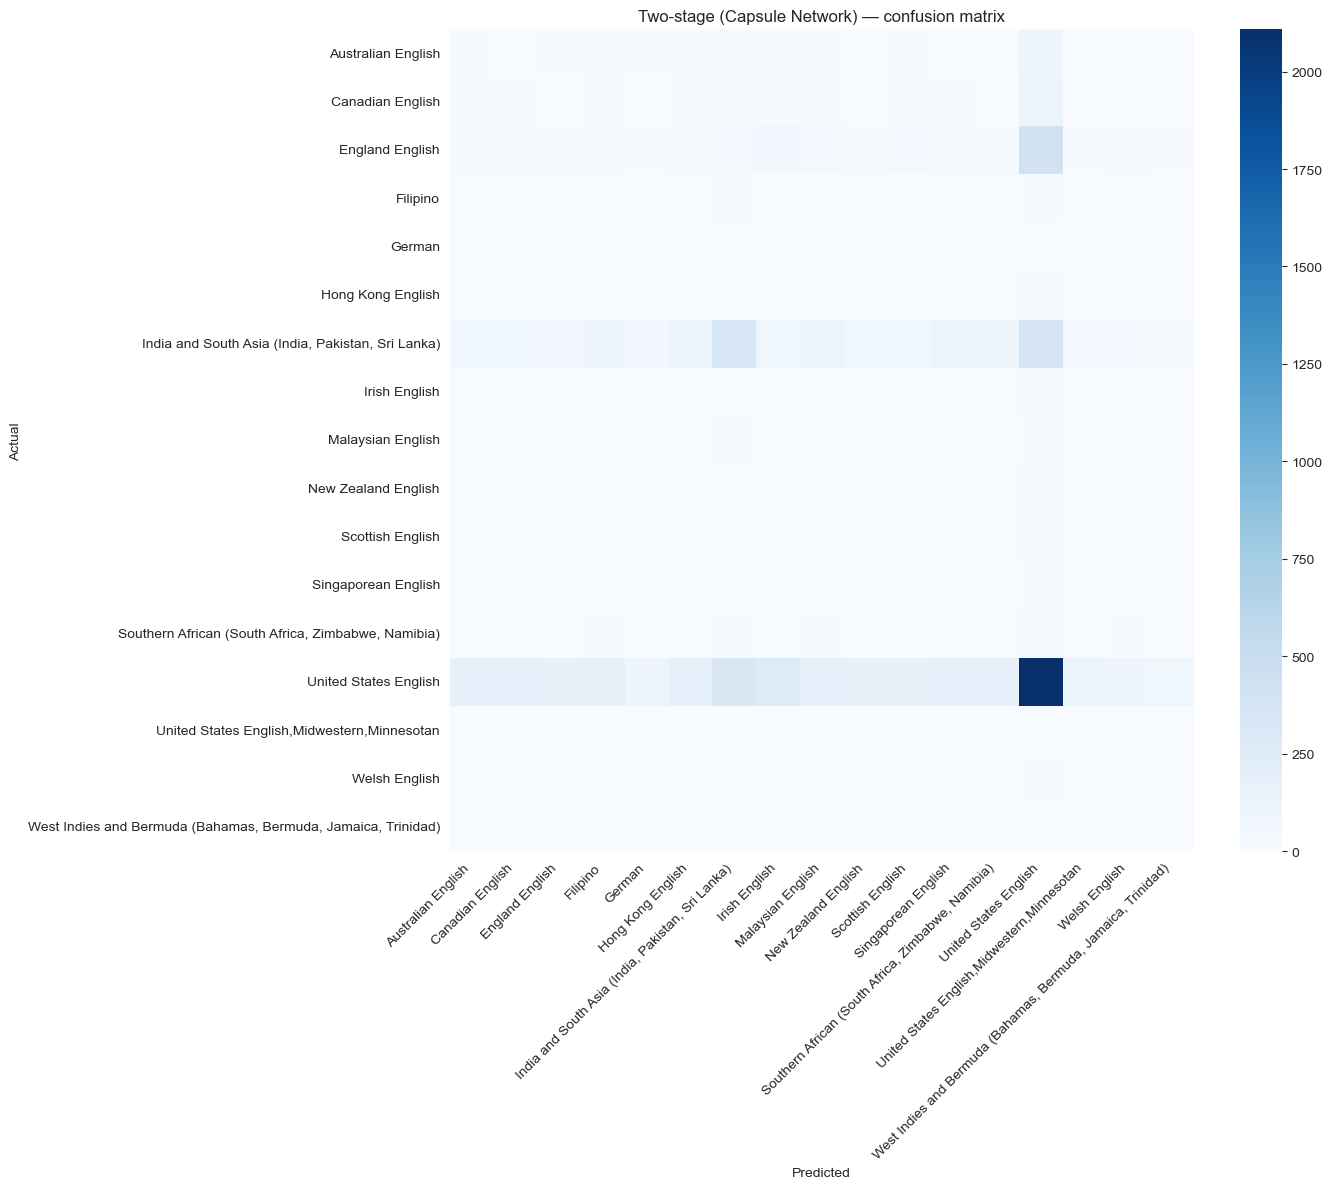

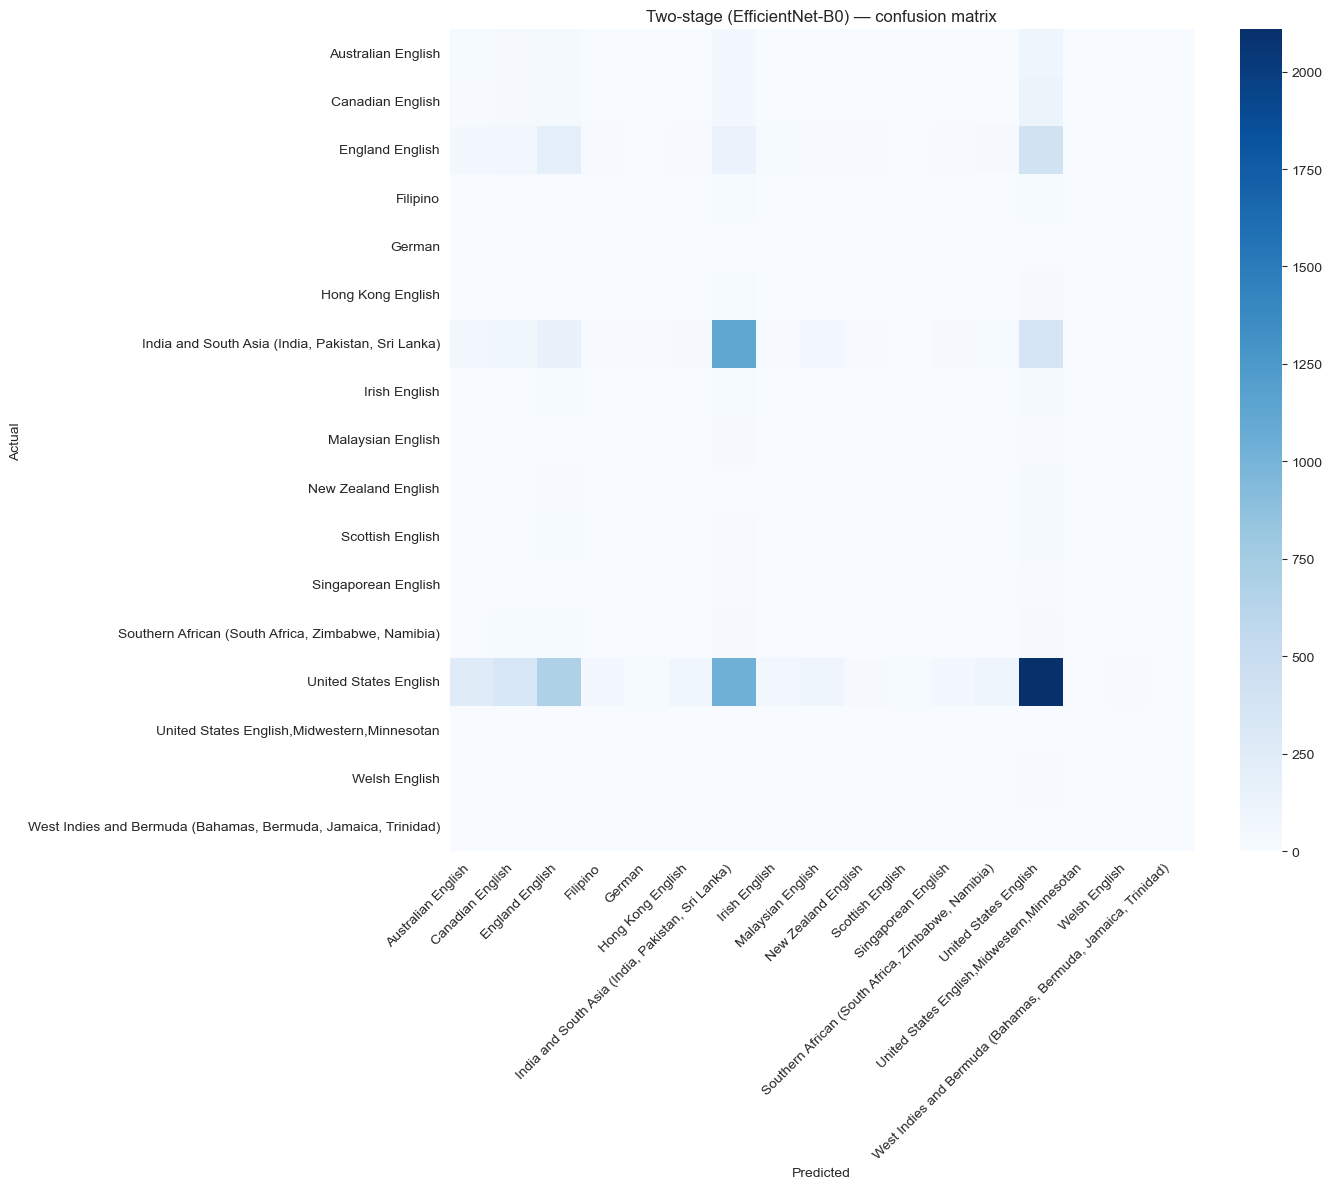

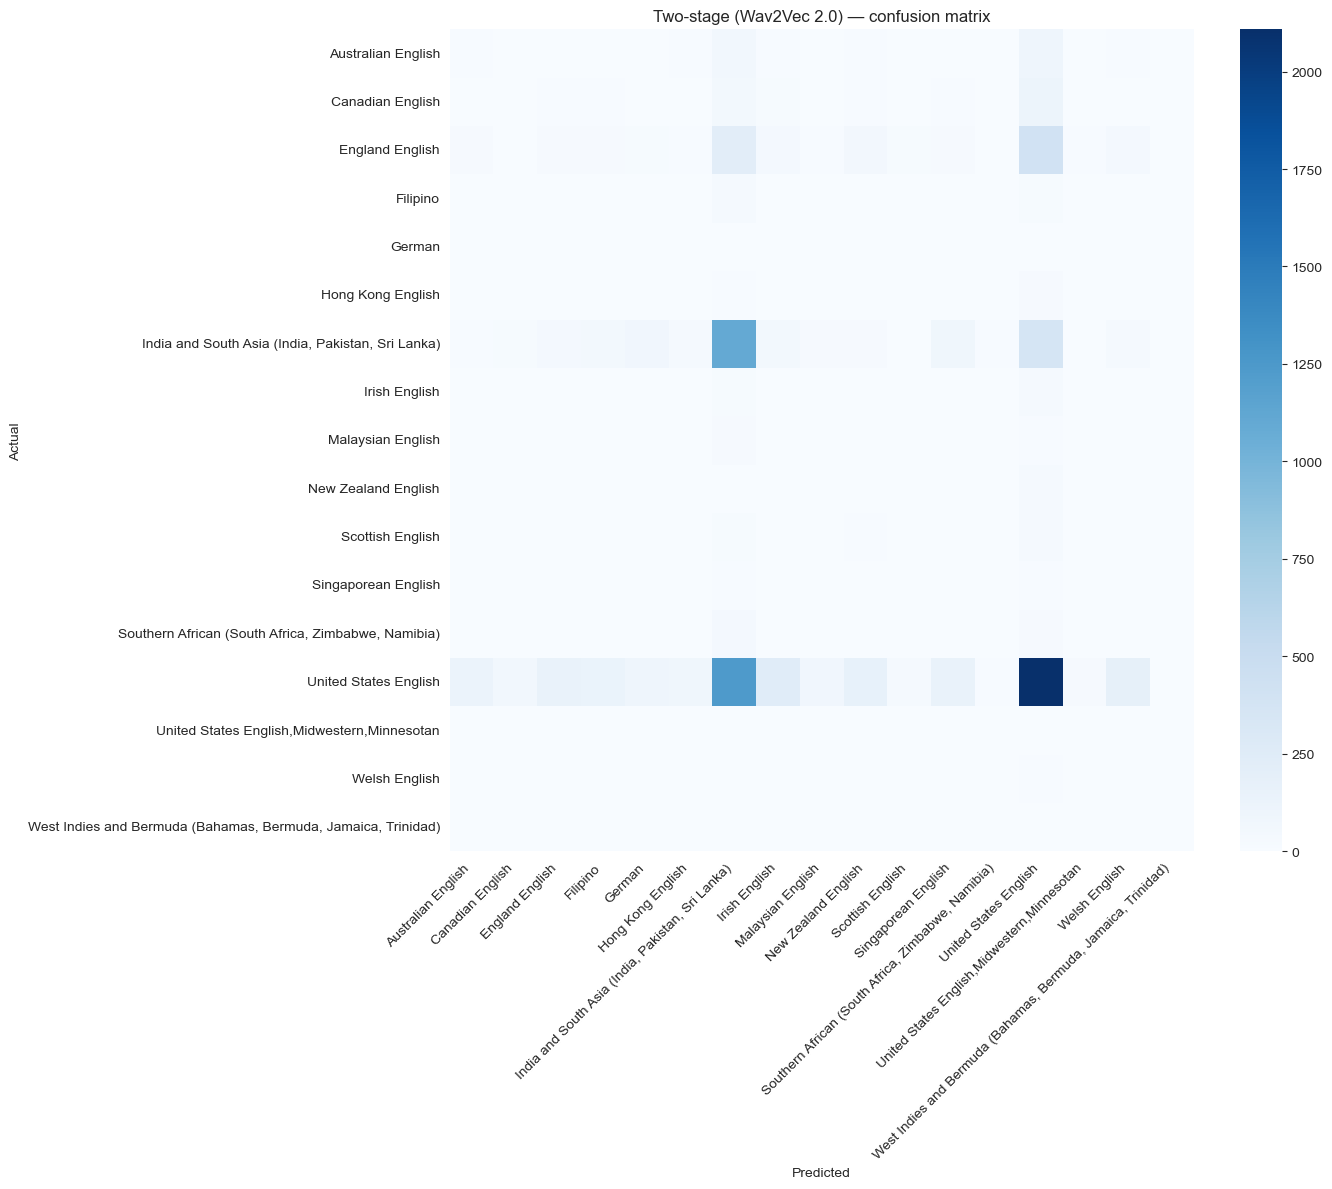

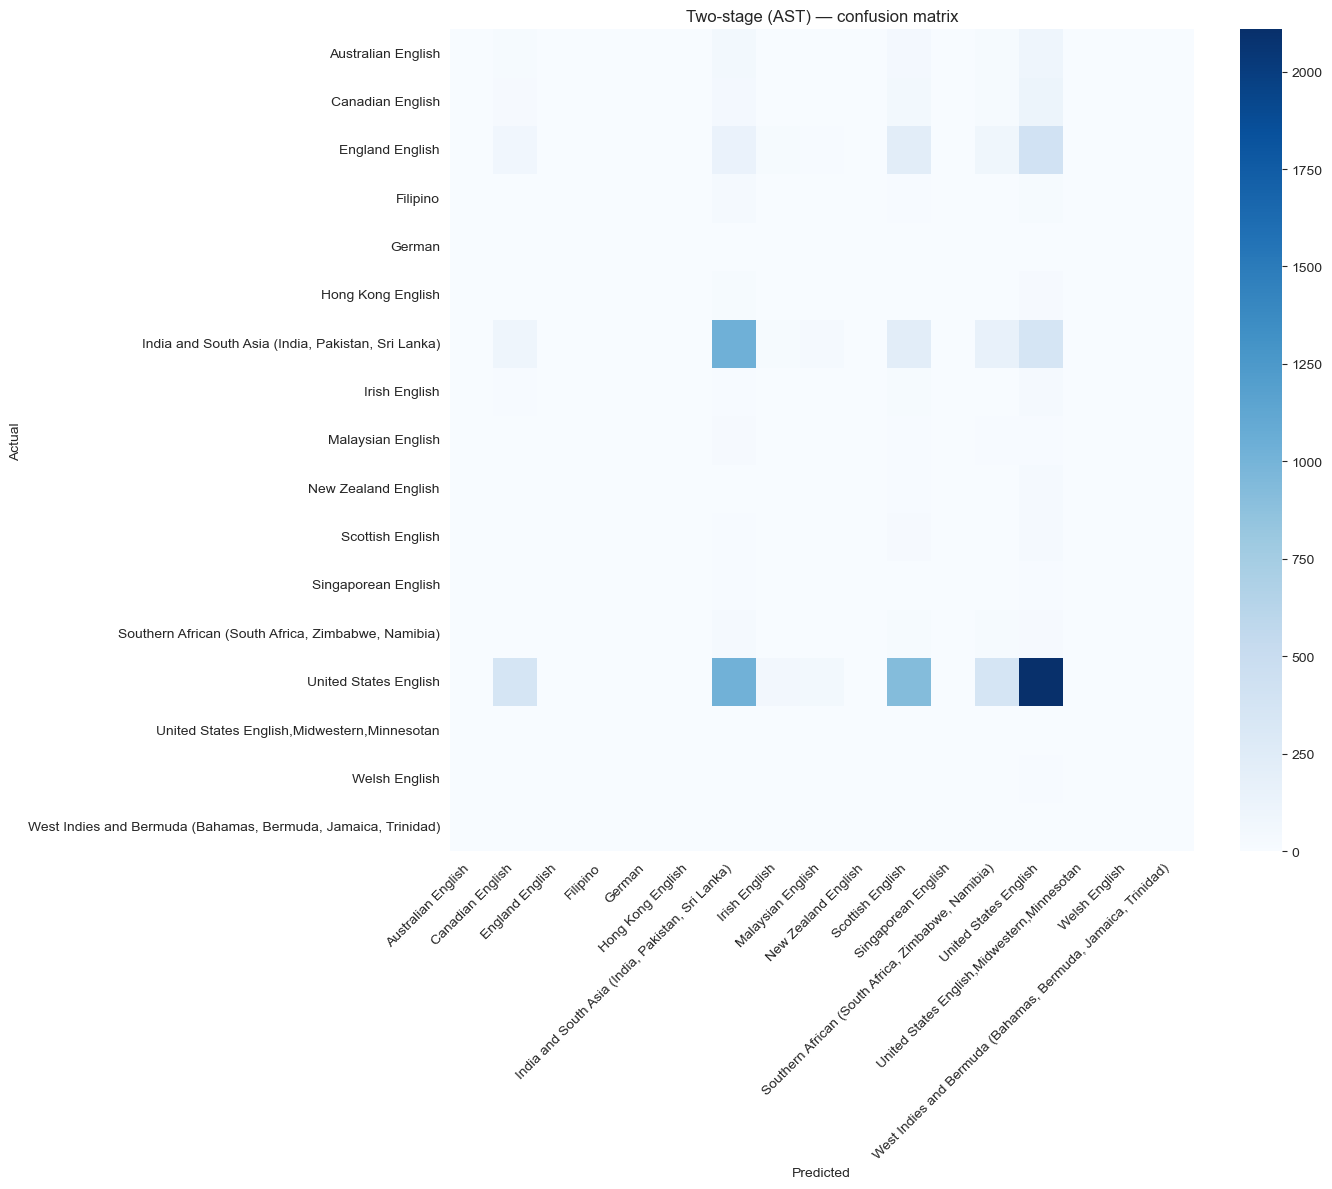

In [22]:
for name, fr in final_results.items():
    cm = confusion_matrix(y_true_full, fr['pred_full'], labels=range(len(le_full.classes_)))
    fig, ax = plt.subplots(figsize=(14, 12))
    sns.heatmap(cm, annot=False, cmap='Blues', ax=ax,
                xticklabels=le_full.classes_, yticklabels=le_full.classes_)
    ax.set_title(f'Two-stage ({name}) — confusion matrix')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.xticks(rotation=45, ha='right'); plt.yticks(rotation=0)
    plt.tight_layout(); plt.show()

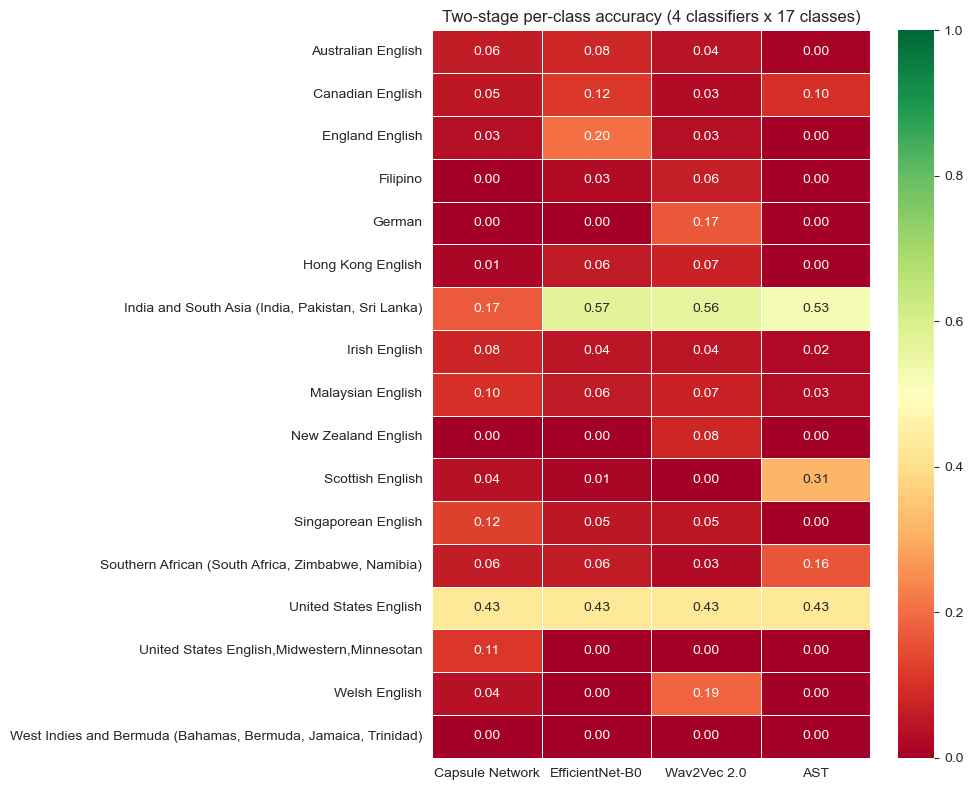

                                                               Capsule Network  EfficientNet-B0  Wav2Vec 2.0    AST
Australian English                                                       0.059            0.078        0.039  0.004
Canadian English                                                         0.051            0.116        0.025  0.101
England English                                                          0.035            0.203        0.032  0.003
Filipino                                                                 0.000            0.026        0.064  0.000
German                                                                   0.000            0.000        0.167  0.000
Hong Kong English                                                        0.014            0.057        0.071  0.000
India and South Asia (India, Pakistan, Sri Lanka)                        0.171            0.571        0.559  0.525
Irish English                                                           

In [23]:
per_class = {}
for name, fr in final_results.items():
    cm = confusion_matrix(y_true_full, fr['pred_full'], labels=range(len(le_full.classes_)))
    per_class[name] = cm.diagonal() / cm.sum(axis=1).clip(min=1)

per_class_df = pd.DataFrame(per_class, index=le_full.classes_)

fig, ax = plt.subplots(figsize=(10, max(8, len(le_full.classes_) * 0.45)))
sns.heatmap(per_class_df, annot=True, fmt='.2f', cmap='RdYlGn',
            vmin=0, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Two-stage per-class accuracy (4 classifiers x 17 classes)')
plt.tight_layout(); plt.show()
print(per_class_df.round(3).to_string())

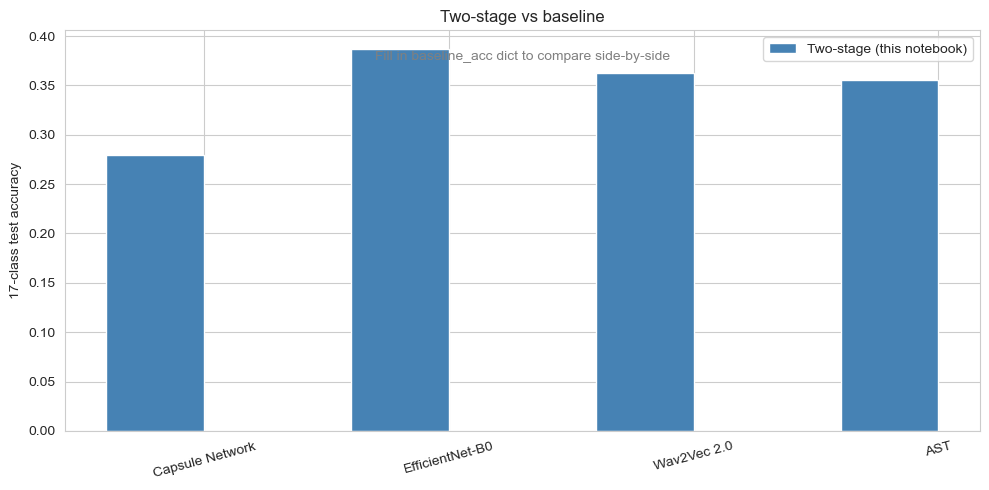

  Capsule Network: 0.280
  EfficientNet-B0: 0.386
  Wav2Vec 2.0: 0.363
  AST: 0.355


In [24]:
baseline_acc = {
    'Capsule Network': None,
    'EfficientNet-B0': None,
    'Wav2Vec 2.0': None,
    'AST': None,
}
two_stage_acc = {n: fr['overall_acc'] for n, fr in final_results.items()}

names = list(two_stage_acc.keys())
ts = [two_stage_acc[n] for n in names]
bl = [baseline_acc.get(n) for n in names]

x = np.arange(len(names))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, ts, 0.4, label='Two-stage (this notebook)', color='steelblue')
if all(v is not None for v in bl):
    ax.bar(x + 0.2, bl, 0.4, label='Baseline (original notebook)', color='coral')
else:
    ax.text(0.5, 0.95, 'Fill in baseline_acc dict to compare side-by-side',
            transform=ax.transAxes, ha='center', va='top', color='gray')
ax.set_xticks(x); ax.set_xticklabels(names, rotation=15)
ax.set_ylabel('17-class test accuracy')
ax.set_title('Two-stage vs baseline')
ax.legend()
plt.tight_layout(); plt.show()
for n, a in two_stage_acc.items():
    print(f"  {n}: {a:.3f}")

## Summary

Key change vs. v1: **the VAE now operates on Wav2Vec 2.0 embeddings, not raw mel spectrograms.** This is the only realistic way to get accent-sensitive reconstruction error — raw mel spectrograms are dominated by speaker / content / mic variance, with accent as a minor perturbation. Wav2Vec embeddings have already stripped most of the speaker / content axes, so accent is a much larger fraction of the signal.

Diagnostics to inspect:
- Gate ROC-AUC should now be **>= 0.75**. If still < 0.7, accent really is hard to separate by reconstruction in this dataset; switch to a learned binary USE-vs-rest gate.
- Per-class accuracy on non-USE classes should improve over baseline — that's the main success criterion.
